# Notebook 3  - Room Masks and Wall Assignment

**Stage 3 file · runs 3rd** (after Notebooks 1 and 2).


> **Pipeline execution order: `1 -> 2 -> 3 -> 4`.**
> This wall-assignment stage begins "obtain room mask `M_i`", and room masks are produced
> only by the watershed (Notebook 2). So the watershed runs first (stage 2) and wall
> assignment second (stage 3). Each notebook also loads what it needs from the previous
> stage's ZIP, so a stage can be re-run on its own as long as the stages it depends on have
> been run once.


## Purpose
Assign each room its wall geometry with the **new boundary-ring** method, then back-project
those wall pixels into 3-D. This replaces the original raster-overlap assignment.

### New wall-assignment (per room mask `M_i`)
1. `M_i` = room mask (from the watershed labels).
2. `I_i` = `erode(M_i, room_erode_px)` — reliable interior.
3. `B_i` = `M_i \ I_i` — boundary ring.
4. `B_i' = dilate(B_i, r_w)` — reach outward by `r_w`.
5. Keep the **wall-mask** pixels inside `B_i'` -> the room's wall pixels.
6. Back-project only those pixels into 3-D (within the floor<->ceiling band).

`room_erode_m` and `wall_dilate_m` (`r_w`) are configurable; leaving either `None`
auto-derives it from the estimated wall thickness  - the same distance-transform heuristic
the original used inside `room_footprints`.

## Inputs
- `wall_mask.npy` + `transform.json` from `stage1_occupancy.zip` (the wall source).
- `room_labels.npy` from `stage2_watershed.zip` (the room masks `M_i`).
- The **point cloud** from `CFG.file_path` (reloaded with the original loader; deterministic).

## Outputs  (`{out_root}/stage3_walls/`, zipped to `stage3_walls.zip`)
- `room_XX_walls.ply`  - per-room 3-D wall points.
- `room_wall_masks.npz`  - per-room wall-pixel masks (keyed `room_<id>`).
- `room_labels.npy` (the masks used), `transform.json`, `config.json`.

## Assumptions
- Stage 1 and Stage 2 used the same `CFG`; the transform from Stage 1 aligns pixels to
  the reloaded cloud.

### Setup
**Run-All ready.** Edit **`params.yaml`** (the only config surface), then run every cell top
to bottom  - no cell edits, ever. `load_config()` reads it over the `Config` defaults.

> **Skipped `pip install -e .`?** Prepend this 2-line path-shim to the cell below so
> `import scan2bim` resolves from `notebooks/methods/geometric/`:
> `import sys, os; sys.path.insert(0, os.path.abspath('../../..'))`

In [1]:
import sys, os
import numpy as np

PROJECT_ROOT = os.path.abspath('../../..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.path = [p for p in sys.path if not p.endswith('/src') and not p.endswith('\\src')]
for mod in list(sys.modules):
    if mod == 'scan2bim' or mod.startswith('scan2bim.'):
        del sys.modules[mod]

import scan2bim
from scan2bim import artifacts as A, viz

CFG = scan2bim.load_config()
SHOW_DEBUG = True
print('scan2bim', scan2bim.__version__, 'loaded from', os.path.dirname(scan2bim.__file__))
print('input cloud :', CFG.file_path, '| exists:', os.path.isfile(CFG.file_path))
print('output root :', CFG.out_root)

scan2bim 1.0.0 loaded from c:\onestruction\scan2bim
input cloud : c:\onestruction\data\area1.xyz | exists: True
output root : c:\onestruction\scan2bim_out


### Step 1  - Load inputs (watershed masks)
Wall assignment **always** runs on the **watershed** room masks (stage 2). SAM-refined walls
are produced by **Notebook 5**, not by editing a switch here. The guards below fail loudly if
an upstream stage was produced from a different cloud / grid.

In [2]:
s1 = A.load_stage_dir(CFG.out_root, A.STAGE1)
wall_mask = A.load_npy(os.path.join(s1, A.WALLMASK_NPY)).astype(bool)
tf = A.load_transform(os.path.join(s1, A.TRANSFORM_JSON))

# Room masks always come from the watershed (stage 2).
s2 = A.load_stage_dir(CFG.out_root, A.STAGE2)
scan2bim.assert_upstream_config(CFG, A.load_stage_config(s1))   # same cloud + grid as stage 1
scan2bim.assert_upstream_config(CFG, A.load_stage_config(s2))   # ...and stage 2
labels = A.load_npy(os.path.join(s2, A.ROOM_LABELS_NPY)).astype('int32')
print('room masks from: watershed (stage 2) | rooms:',
      len([r for r in np.unique(labels) if r >= 1]))

# Reload the cloud with the SAME loader N1 used (deterministic -> aligns to tf), then assert
# it actually lands inside the stage-1 grid (catches a mismatched cloud before it produces
# near-empty walls).
pcd, pts = scan2bim.load_point_cloud(CFG)
scan2bim.assert_points_in_grid(pts, tf)

room masks from: watershed (stage 2) | rooms: 53
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
units/meter = 1.0  (raw max extent 48.69)
points before clean: 5,183,987
points after voxel (0.02 m): 5,058,586


0.9994296825239306

### Step 2  - Boundary-ring wall masks (the new assignment)

In [3]:
wall_masks, dbg = scan2bim.room_wall_masks_boundary_ring(labels, wall_mask, CFG, return_debug=True)
print('rooms:', len(wall_masks), '| erode_px=%d  r_w(dilate_px)=%d' % (dbg['erode_px'], dbg['dilate_px']))

rooms: 53 | erode_px=3  r_w(dilate_px)=7


### Step 3  - Back-project the assigned wall pixels into 3-D

In [4]:
band, floor_z, ceil_z = scan2bim.height_band_mask(pts, CFG, tf)
rooms3d = scan2bim.backproject_room_masks(pts, wall_masks, tf, keep_mask=band)
for e in rooms3d:
    print('room %02d: %7d wall points' % (e['room_id'], len(e['points'])))

room 01:   17502 wall points
room 02:   72665 wall points
room 03:   51693 wall points
room 04:   26302 wall points
room 05:   13121 wall points
room 06:   55227 wall points
room 07:   10656 wall points
room 08:    8433 wall points
room 09:   54448 wall points
room 10:   11379 wall points
room 11:   60799 wall points
room 12:   52188 wall points
room 13:   70833 wall points
room 14:   59040 wall points
room 15:   44968 wall points
room 16:   41913 wall points
room 17:   61247 wall points
room 18:   62046 wall points
room 19:   54496 wall points
room 20:   50169 wall points
room 21:   68738 wall points
room 22:   48367 wall points
room 23:   54096 wall points
room 24:   39936 wall points
room 25:    3320 wall points
room 26:   46661 wall points
room 27:   19528 wall points
room 28:   20680 wall points
room 29:   30629 wall points
room 30:   25232 wall points
room 31:   25247 wall points
room 32:   58810 wall points
room 33:   18559 wall points
room 34:   59456 wall points
room 35:   596

### Optional  - QA plot of the boundary-ring assignment

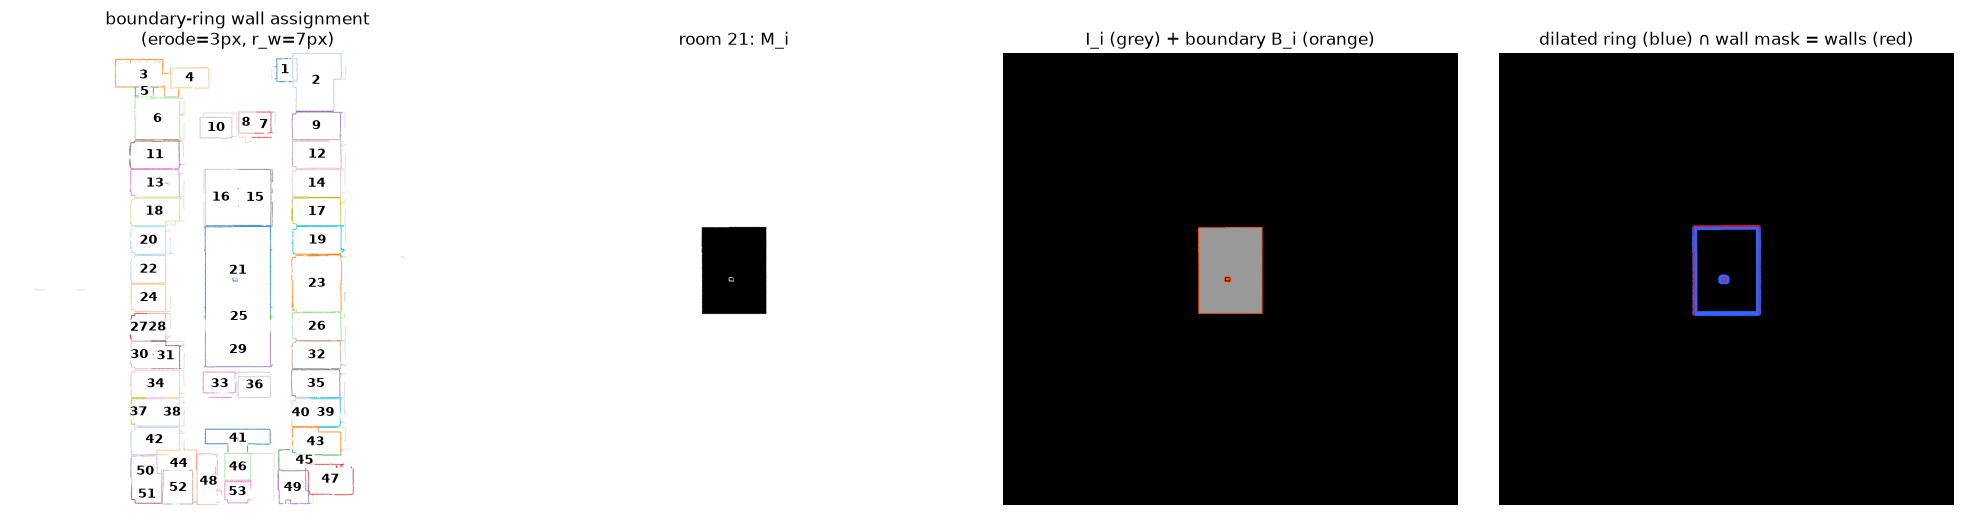

In [5]:
if SHOW_DEBUG:
    viz.show_wall_assignment(labels, wall_masks, debug=dbg)

### Step 4  - Save per-room wall clouds + masks and package the ZIP

In [6]:
import open3d as o3d
out_dir = A.ensure_dir(A.stage_dir(CFG.out_root, A.STAGE3))
A.save_room_wall_masks(os.path.join(out_dir, A.ROOM_WALL_MASKS_NPZ), wall_masks)

n_written = 0
for e in rooms3d:
    if len(e['points']) == 0:
        continue
    pc = o3d.geometry.PointCloud()
    pc.points = o3d.utility.Vector3dVector(e['points'])
    o3d.io.write_point_cloud(os.path.join(out_dir, 'room_%02d_walls.ply' % e['room_id']), pc)
    n_written += 1
print('wrote', n_written, 'room wall clouds')

A.save_npy(os.path.join(out_dir, A.ROOM_LABELS_NPY), labels)
A.save_transform(os.path.join(out_dir, A.TRANSFORM_JSON), tf,
                 extra=dict(floor_z=float(floor_z), ceil_z=float(ceil_z)))
A.save_config(os.path.join(out_dir, A.CONFIG_JSON), CFG)
zip_path = A.package_stage(CFG.out_root, A.STAGE3)
print('packaged ->', zip_path)

wrote 53 room wall clouds
packaged -> c:\onestruction\scan2bim_out\stage3_walls.zip


### Optional  - download the wall-cloud ZIP (Colab)
Downloads the packaged `stage3_walls.zip` (the per-room geometric wall clouds). Triggers a
browser download in Colab; outside Colab it just prints the local path.

In [7]:
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print('Not in Colab - find the ZIP at:', zip_path)

Not in Colab - find the ZIP at: c:\onestruction\scan2bim_out\stage3_walls.zip


### Optional  - per-room RANSAC wall planes
The original notebook could also fit vertical planes per room (`fit_walls_in_room`). This
is off by default; enable it for plane-level wall geometry.

In [8]:
# DO_RANSAC = False
# if DO_RANSAC:
#     import open3d as o3d
#     for e in rooms3d:
#         if len(e['points']) < CFG.ransac_min_inliers:
#             continue
#         pc = o3d.geometry.PointCloud()
#         pc.points = o3d.utility.Vector3dVector(e['points'])
#         planes = scan2bim.fit_walls_in_room(
#             pc, up_axis=CFG.up_axis, normal_tol_deg=CFG.ransac_normal_tol_deg,
#             dist_thresh=CFG.ransac_dist_thresh_m, min_inliers=CFG.ransac_min_inliers,
#             max_planes=CFG.ransac_max_planes)
#         print('room %02d: %d wall planes' % (e['room_id'], len(planes)))